### Импорты и пути

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

project_root = Path.cwd().parent
data_path = project_root / "data" / "raw" / "bank-additional-full.csv"
description_path = project_root / "data" / "raw" / "bank-additional-names.txt"

outputs_path = project_root / "outputs"
figures_path = outputs_path / "figures"
tables_path = outputs_path / "tables"

figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

data_path

PosixPath('/home/coder/Code/poject_andan/data/raw/bank-additional-full.csv')

### Загрузка данных

In [2]:
df = pd.read_csv(data_path, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Размер данных

In [3]:
rows, cols = df.shape

print(f"Количество строк: {rows:,}")
print(f"Количество колонок: {cols}")

df.info()

Количество строк: 41,188
Количество колонок: 21
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64

### Список колонок

In [4]:
columns_overview = pd.DataFrame({
  "column": df.columns,
  "dtype": df.dtypes.astype(str).values,
  "missing": df.isna().sum().values,
  "missing_share": df.isna().mean().values
})

columns_overview

,column,dtype,missing,missing_share
0,age,int64,0,0.0
1,job,str,0,0.0
2,marital,str,0,0.0
3,education,str,0,0.0
4,default,str,0,0.0
5,housing,str,0,0.0
6,loan,str,0,0.0
7,contact,str,0,0.0
8,month,str,0,0.0
9,day_of_week,str,0,0.0


### Целевая переменная

In [5]:
target_counts = df["y"].value_counts()
target_share = df["y"].value_counts(normalize=True)

target_summary = pd.DataFrame({
  "count": target_counts,
  "share": target_share
})

target_summary

,count,share
y,,
no,36548,0.887346
yes,4640,0.112654


### Конверсия

In [6]:
conversion = (df["y"] == "yes").mean()
clients_count = len(df)
success_count = (df["y"] == "yes").sum()

print(f"Всего клиентов: {clients_count:,}")
print(f"Оформили депозит: {success_count:,}")
print(f"Конверсия: {conversion:.2%}")

Всего клиентов: 41,188
Оформили депозит: 4,640
Конверсия: 11.27%


### Создаём числовую целевую переменную

In [7]:
df = df.copy()

df["target"] = (df["y"] == "yes").astype(int)

df[["y", "target"]].head()

,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


### Проверяем значения unknown

In [8]:
object_columns = df.select_dtypes(include="object").columns

unknown_summary = []

for column in object_columns:
  unknown_count = (df[column] == "unknown").sum()
  unknown_summary.append({
    "column": column,
    "unknown_count": unknown_count,
    "unknown_share": unknown_count / len(df)
  })

unknown_summary = pd.DataFrame(unknown_summary)
unknown_summary = unknown_summary.sort_values("unknown_share", ascending=False)

unknown_summary

/tmp/ipykernel_32825/1094421200.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns


,column,unknown_count,unknown_share
3,default,8597,0.208726
2,education,1731,0.042027
4,housing,990,0.024036
5,loan,990,0.024036
0,job,330,0.008012
1,marital,80,0.001942
6,contact,0,0.000000
7,month,0,0.000000
8,day_of_week,0,0.000000
9,poutcome,0,0.000000


### Обзор категориальных признаков

In [9]:
categorical_overview = []

for column in object_columns:
  values = df[column].value_counts(normalize=True)
  categorical_overview.append({
    "column": column,
    "unique_values": df[column].nunique(),
    "top_value": values.index[0],
    "top_value_share": values.iloc[0]
  })

categorical_overview = pd.DataFrame(categorical_overview)
categorical_overview

,column,unique_values,top_value,top_value_share
0,job,12,admin.,0.253035
1,marital,4,married,0.605225
2,education,8,university.degree,0.295426
3,default,3,no,0.791201
4,housing,3,yes,0.523842
5,loan,3,no,0.824269
6,contact,2,cellular,0.634748
7,month,10,may,0.334296
8,day_of_week,5,thu,0.209357
9,poutcome,3,nonexistent,0.863431


### Функция для конверсии по группам

In [10]:
def conversion_by_group(data, column):
  result = (
    data
    .groupby(column)
    .agg(
      clients=("target", "size"),
      deposits=("target", "sum"),
      conversion=("target", "mean")
    )
    .reset_index()
  )

  result["client_share"] = result["clients"] / len(data)
  result["deposit_share"] = result["deposits"] / data["target"].sum()

  result = result.sort_values("conversion", ascending=False)

  return result

### Конверсия по типу контакта

In [11]:
contact_conversion = conversion_by_group(df, "contact")

contact_conversion

,contact,clients,deposits,conversion,client_share,deposit_share
0,cellular,26144,3853,0.147376,0.634748,0.830388
1,telephone,15044,787,0.052313,0.365252,0.169612


### Конверсия по месяцу

In [12]:
month_conversion = conversion_by_group(df, "month")

month_conversion

,month,clients,deposits,conversion,client_share,deposit_share
5,mar,546,276,0.505495,0.013256,0.059483
2,dec,182,89,0.489011,0.004419,0.019181
9,sep,570,256,0.449123,0.013839,0.055172
8,oct,718,315,0.438719,0.017432,0.067888
0,apr,2632,539,0.204787,0.063902,0.116164
1,aug,6178,655,0.106021,0.149995,0.141164
4,jun,5318,559,0.105115,0.129115,0.120474
7,nov,4101,416,0.101439,0.099568,0.089655
3,jul,7174,649,0.090466,0.174177,0.139871
6,may,13769,886,0.064347,0.334296,0.190948


### Конверсия по профессии

In [13]:
job_conversion = conversion_by_group(df, "job")

job_conversion

,job,clients,deposits,conversion,client_share,deposit_share
8,student,875,275,0.314286,0.021244,0.059267
5,retired,1720,434,0.252326,0.041760,0.093534
10,unemployed,1014,144,0.142012,0.024619,0.031034
0,admin.,10422,1352,0.129726,0.253035,0.291379
4,management,2924,328,0.112175,0.070992,0.070690
11,unknown,330,37,0.112121,0.008012,0.007974
9,technician,6743,730,0.108260,0.163713,0.157328
6,self-employed,1421,149,0.104856,0.034500,0.032112
3,housemaid,1060,106,0.100000,0.025736,0.022845
2,entrepreneur,1456,124,0.085165,0.035350,0.026724


### Конверсия по образованию

In [14]:
education_conversion = conversion_by_group(df, "education")

education_conversion

,education,clients,deposits,conversion,client_share,deposit_share
4,illiterate,18,4,0.222222,0.000437,0.000862
7,unknown,1731,251,0.145003,0.042027,0.054095
6,university.degree,12168,1670,0.137245,0.295426,0.359914
5,professional.course,5243,595,0.113485,0.127294,0.128233
3,high.school,9515,1031,0.108355,0.231014,0.222198
0,basic.4y,4176,428,0.102490,0.101389,0.092241
1,basic.6y,2292,188,0.082024,0.055647,0.040517
2,basic.9y,6045,473,0.078246,0.146766,0.101940


### Конверсия по результату прошлой кампании

In [15]:
poutcome_conversion = conversion_by_group(df, "poutcome")

poutcome_conversion

,poutcome,clients,deposits,conversion,client_share,deposit_share
2,success,1373,894,0.651129,0.033335,0.192672
0,failure,4252,605,0.142286,0.103234,0.130388
1,nonexistent,35563,3141,0.088322,0.863431,0.676940


### Числовые признаки по целевой переменной

In [16]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.drop("target")

numeric_by_target = (
  df
  .groupby("y")[numeric_columns]
  .mean()
  .T
)

numeric_by_target["difference_yes_minus_no"] = numeric_by_target["yes"] - numeric_by_target["no"]

numeric_by_target.sort_values("difference_yes_minus_no", ascending=False)

y,no,yes,difference_yes_minus_no
duration,220.844807,553.191164,332.346357
age,39.911185,40.913147,1.001961
cons.conf.idx,-40.593097,-39.789784,0.803312
previous,0.132374,0.492672,0.360299
cons.price.idx,93.603757,93.354386,-0.249371
campaign,2.633085,2.051724,-0.581361
emp.var.rate,0.248875,-1.233448,-1.482324
euribor3m,3.811491,2.123135,-1.688356
nr.employed,5176.166600,5095.115991,-81.050609
pdays,984.113878,792.035560,-192.078317


### Сохраняем таблицы

In [17]:
unknown_summary.to_csv(tables_path / "unknown_summary.csv", index=False)
categorical_overview.to_csv(tables_path / "categorical_overview.csv", index=False)
contact_conversion.to_csv(tables_path / "contact_conversion.csv", index=False)
month_conversion.to_csv(tables_path / "month_conversion.csv", index=False)
job_conversion.to_csv(tables_path / "job_conversion.csv", index=False)
education_conversion.to_csv(tables_path / "education_conversion.csv", index=False)
poutcome_conversion.to_csv(tables_path / "poutcome_conversion.csv", index=False)
numeric_by_target.to_csv(tables_path / "numeric_by_target.csv")

print("Таблицы сохранены")

Таблицы сохранены


### Общая воронка кампании

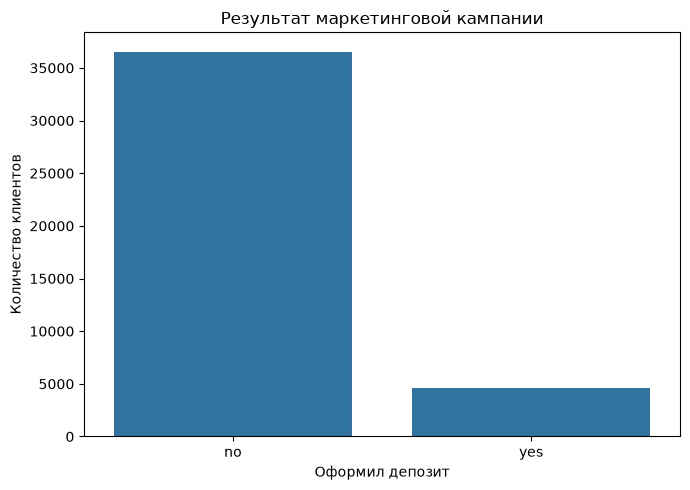

In [18]:
target_plot = (
  df["y"]
  .value_counts()
  .rename_axis("result")
  .reset_index(name="clients")
)

plt.figure(figsize=(7, 5))
sns.barplot(data=target_plot, x="result", y="clients")
plt.title("Результат маркетинговой кампании")
plt.xlabel("Оформил депозит")
plt.ylabel("Количество клиентов")
plt.tight_layout()
plt.savefig(figures_path / "01_campaign_result.png", dpi=200)
plt.show()

### Конверсия по типу контакта

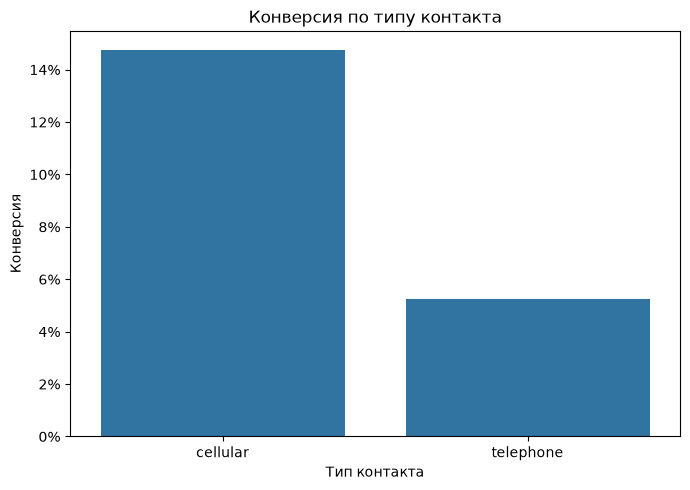

In [19]:
contact_plot = contact_conversion.sort_values("conversion", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=contact_plot, x="contact", y="conversion")
plt.title("Конверсия по типу контакта")
plt.xlabel("Тип контакта")
plt.ylabel("Конверсия")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "02_contact_conversion.png", dpi=200)
plt.show()

### Конверсия по месяцам

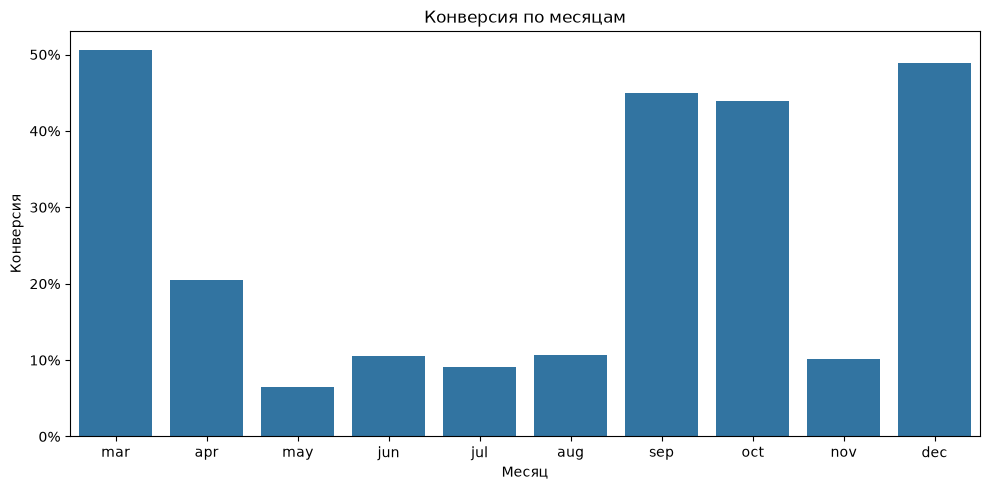

In [20]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

month_plot = month_conversion.copy()
month_plot["month"] = pd.Categorical(month_plot["month"], categories=month_order, ordered=True)
month_plot = month_plot.sort_values("month")

plt.figure(figsize=(10, 5))
sns.barplot(data=month_plot, x="month", y="conversion")
plt.title("Конверсия по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Конверсия")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "03_month_conversion.png", dpi=200)
plt.show()

### Конверсия по профессиям

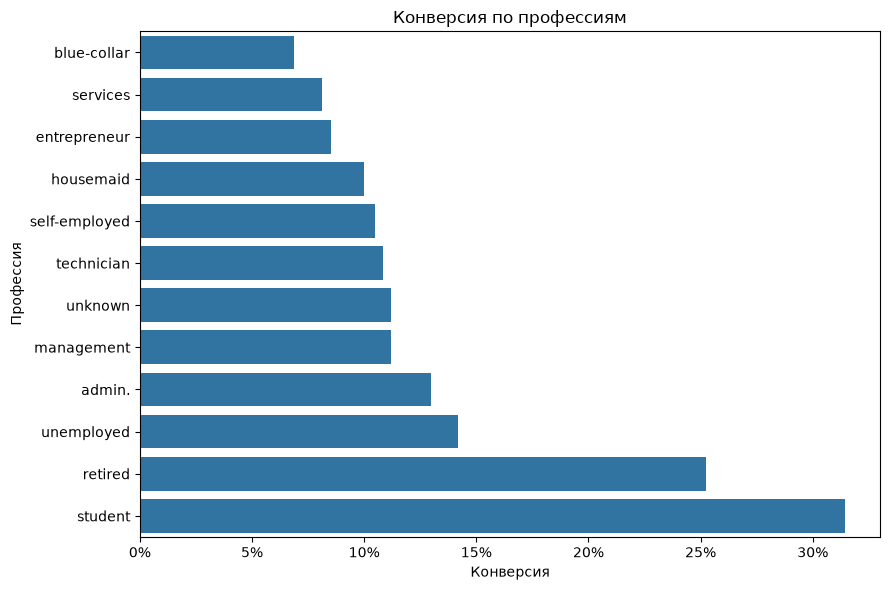

In [21]:
job_plot = job_conversion.sort_values("conversion", ascending=True)

plt.figure(figsize=(9, 6))
sns.barplot(data=job_plot, x="conversion", y="job")
plt.title("Конверсия по профессиям")
plt.xlabel("Конверсия")
plt.ylabel("Профессия")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "04_job_conversion.png", dpi=200)
plt.show()

### Влияние прошлой кампании

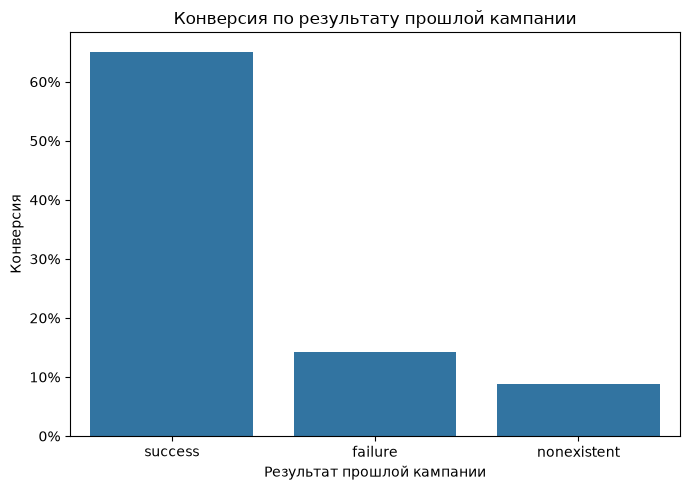

In [22]:
poutcome_plot = poutcome_conversion.sort_values("conversion", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=poutcome_plot, x="poutcome", y="conversion")
plt.title("Конверсия по результату прошлой кампании")
plt.xlabel("Результат прошлой кампании")
plt.ylabel("Конверсия")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "05_poutcome_conversion.png", dpi=200)
plt.show()

### Сравнение числовых признаков

In [23]:
numeric_target_plot = numeric_by_target[["no", "yes"]].copy()

numeric_target_plot = numeric_target_plot.reset_index()
numeric_target_plot = numeric_target_plot.rename(columns={"index": "feature"})

numeric_target_plot

y,feature,no,yes
0,age,39.911185,40.913147
1,duration,220.844807,553.191164
2,campaign,2.633085,2.051724
3,pdays,984.113878,792.035560
4,previous,0.132374,0.492672
5,emp.var.rate,0.248875,-1.233448
6,cons.price.idx,93.603757,93.354386
7,cons.conf.idx,-40.593097,-39.789784
8,euribor3m,3.811491,2.123135
9,nr.employed,5176.166600,5095.115991


### Важный вывод про duration

In [24]:
duration_conversion = (
  df
  .assign(duration_group=pd.qcut(df["duration"], q=5, duplicates="drop"))
  .groupby("duration_group")
  .agg(
    clients=("target", "size"),
    deposits=("target", "sum"),
    conversion=("target", "mean"),
    avg_duration=("duration", "mean")
  )
  .reset_index()
)

duration_conversion

,duration_group,clients,deposits,conversion,avg_duration
0,"(-0.001, 89.0]",8388,44,0.005246,55.000358
1,"(89.0, 146.0]",8139,264,0.032436,117.269935
2,"(146.0, 222.0]",8274,602,0.072758,181.724801
3,"(222.0, 368.0]",8165,1017,0.124556,285.645560
4,"(368.0, 4918.0]",8222,2713,0.329968,655.139017


### График duration

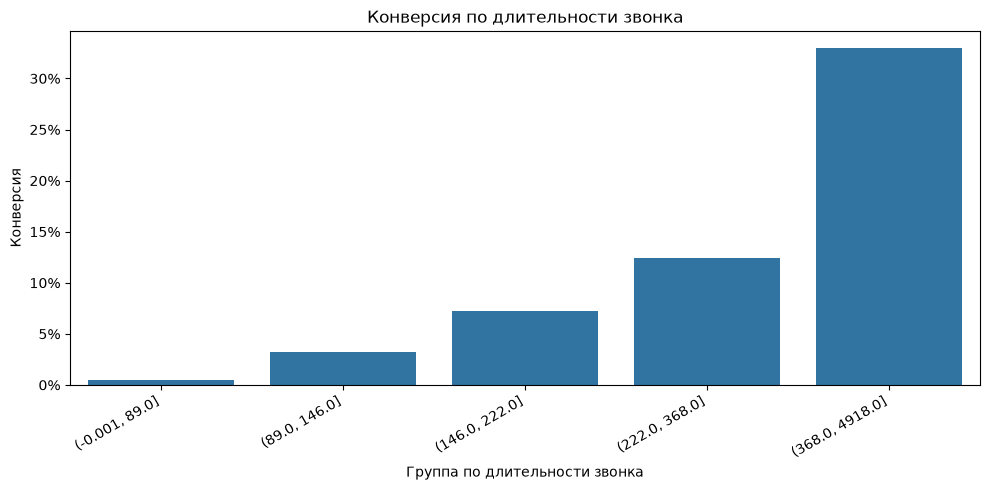

In [25]:
duration_plot = duration_conversion.copy()
duration_plot["duration_group"] = duration_plot["duration_group"].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(data=duration_plot, x="duration_group", y="conversion")
plt.title("Конверсия по длительности звонка")
plt.xlabel("Группа по длительности звонка")
plt.ylabel("Конверсия")
plt.xticks(rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "06_duration_conversion.png", dpi=200)
plt.show()

### Базовая экономика кампании

In [26]:
call_cost = 3
revenue_per_deposit = 80

clients = len(df)
deposits = df["target"].sum()
conversion = df["target"].mean()

total_cost = clients * call_cost
total_revenue = deposits * revenue_per_deposit
profit = total_revenue - total_cost
roi = profit / total_cost
break_even_conversion = call_cost / revenue_per_deposit

economics_summary = pd.DataFrame({
  "metric": [
    "clients",
    "deposits",
    "conversion",
    "call_cost",
    "revenue_per_deposit",
    "total_cost",
    "total_revenue",
    "profit",
    "roi",
    "break_even_conversion"
  ],
  "value": [
    clients,
    deposits,
    conversion,
    call_cost,
    revenue_per_deposit,
    total_cost,
    total_revenue,
    profit,
    roi,
    break_even_conversion
  ]
})

economics_summary

,metric,value
0,clients,41188.000000
1,deposits,4640.000000
2,conversion,0.112654
3,call_cost,3.000000
4,revenue_per_deposit,80.000000
5,total_cost,123564.000000
6,total_revenue,371200.000000
7,profit,247636.000000
8,roi,2.004111
9,break_even_conversion,0.037500


### Красивый вывод экономики

In [27]:
print(f"Клиентов обзвонили: {clients:,}")
print(f"Депозитов оформили: {deposits:,}")
print(f"Конверсия: {conversion:.2%}")
print(f"Стоимость звонка: {call_cost} €")
print(f"Выручка с депозита: {revenue_per_deposit} €")
print(f"Общие затраты: {total_cost:,.0f} €")
print(f"Общая выручка: {total_revenue:,.0f} €")
print(f"Прибыль: {profit:,.0f} €")
print(f"ROI: {roi:.2%}")
print(f"Конверсия безубыточности: {break_even_conversion:.2%}")

Клиентов обзвонили: 41,188
Депозитов оформили: 4,640
Конверсия: 11.27%
Стоимость звонка: 3 €
Выручка с депозита: 80 €
Общие затраты: 123,564 €
Общая выручка: 371,200 €
Прибыль: 247,636 €
ROI: 200.41%
Конверсия безубыточности: 3.75%


### Чувствительность прибыли

In [28]:
call_cost_values = [1, 2, 3, 4, 5, 6, 8, 10]
revenue_values = [40, 60, 80, 100, 120, 150, 200]

sensitivity = []

for current_call_cost in call_cost_values:
  for current_revenue in revenue_values:
    current_profit = deposits * current_revenue - clients * current_call_cost
    current_roi = current_profit / (clients * current_call_cost)

    sensitivity.append({
      "call_cost": current_call_cost,
      "revenue_per_deposit": current_revenue,
      "profit": current_profit,
      "roi": current_roi
    })

sensitivity = pd.DataFrame(sensitivity)

sensitivity_pivot = sensitivity.pivot(
  index="call_cost",
  columns="revenue_per_deposit",
  values="profit"
)

sensitivity_pivot

revenue_per_deposit,40,60,80,100,120,150,200
call_cost,,,,,,,
1,144412,237212,330012,422812,515612,654812,886812
2,103224,196024,288824,381624,474424,613624,845624
3,62036,154836,247636,340436,433236,572436,804436
4,20848,113648,206448,299248,392048,531248,763248
5,-20340,72460,165260,258060,350860,490060,722060
6,-61528,31272,124072,216872,309672,448872,680872
8,-143904,-51104,41696,134496,227296,366496,598496
10,-226280,-133480,-40680,52120,144920,284120,516120


### График чувствительности прибыли

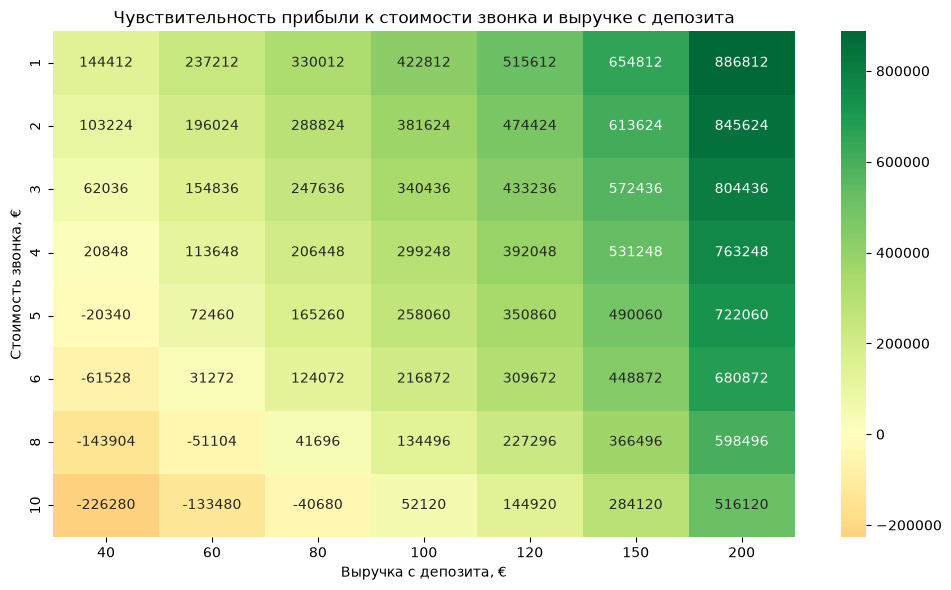

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(sensitivity_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Чувствительность прибыли к стоимости звонка и выручке с депозита")
plt.xlabel("Выручка с депозита, €")
plt.ylabel("Стоимость звонка, €")
plt.tight_layout()
plt.savefig(figures_path / "07_profit_sensitivity.png", dpi=200)
plt.show()

### Функция экономики по сегментам

In [30]:
def segment_economics(data, group_columns, call_cost=3, revenue_per_deposit=80):
  result = (
    data
    .groupby(group_columns)
    .agg(
      clients=("target", "size"),
      deposits=("target", "sum"),
      conversion=("target", "mean")
    )
    .reset_index()
  )

  result["cost"] = result["clients"] * call_cost
  result["revenue"] = result["deposits"] * revenue_per_deposit
  result["profit"] = result["revenue"] - result["cost"]
  result["roi"] = result["profit"] / result["cost"]
  result["profit_per_client"] = result["profit"] / result["clients"]

  return result.sort_values("profit", ascending=False)

### Экономика по типу контакта

In [31]:
contact_economics = segment_economics(df, "contact", call_cost, revenue_per_deposit)

contact_economics

,contact,clients,deposits,conversion,cost,revenue,profit,roi,profit_per_client
0,cellular,26144,3853,0.147376,78432,308240,229808,2.930029,8.790086
1,telephone,15044,787,0.052313,45132,62960,17828,0.395019,1.185057


### Экономика по месяцам

In [32]:
month_economics = segment_economics(df, "month", call_cost, revenue_per_deposit)

month_economics

,month,clients,deposits,conversion,cost,revenue,profit,roi,profit_per_client
0,apr,2632,539,0.204787,7896,43120,35224,4.460993,13.382979
1,aug,6178,655,0.106021,18534,52400,33866,1.827236,5.481709
3,jul,7174,649,0.090466,21522,51920,30398,1.412415,4.237246
6,may,13769,886,0.064347,41307,70880,29573,0.715932,2.147796
4,jun,5318,559,0.105115,15954,44720,28766,1.803059,5.409176
8,oct,718,315,0.438719,2154,25200,23046,10.699164,32.097493
7,nov,4101,416,0.101439,12303,33280,20977,1.705031,5.115094
5,mar,546,276,0.505495,1638,22080,20442,12.479853,37.439560
9,sep,570,256,0.449123,1710,20480,18770,10.976608,32.929825
2,dec,182,89,0.489011,546,7120,6574,12.040293,36.120879


### Экономика по профессиям

In [33]:
job_economics = segment_economics(df, "job", call_cost, revenue_per_deposit)

job_economics

,job,clients,deposits,conversion,cost,revenue,profit,roi,profit_per_client
0,admin.,10422,1352,0.129726,31266,108160,76894,2.459349,7.378046
9,technician,6743,730,0.108260,20229,58400,38171,1.886944,5.660833
5,retired,1720,434,0.252326,5160,34720,29560,5.728682,17.186047
1,blue-collar,9254,638,0.068943,27762,51040,23278,0.838484,2.515453
8,student,875,275,0.314286,2625,22000,19375,7.380952,22.142857
4,management,2924,328,0.112175,8772,26240,17468,1.991336,5.974008
7,services,3969,323,0.081381,11907,25840,13933,1.170152,3.510456
10,unemployed,1014,144,0.142012,3042,11520,8478,2.786982,8.360947
6,self-employed,1421,149,0.104856,4263,11920,7657,1.796153,5.388459
2,entrepreneur,1456,124,0.085165,4368,9920,5552,1.271062,3.813187


### Экономика по прошлой кампании

In [34]:
poutcome_economics = segment_economics(df, "poutcome", call_cost, revenue_per_deposit)

poutcome_economics

,poutcome,clients,deposits,conversion,cost,revenue,profit,roi,profit_per_client
1,nonexistent,35563,3141,0.088322,106689,251280,144591,1.355257,4.065771
2,success,1373,894,0.651129,4119,71520,67401,16.363438,49.090313
0,failure,4252,605,0.142286,12756,48400,35644,2.794293,8.382879


### Комбинированные сегменты

In [35]:
combined_segments = segment_economics(
  df,
  ["contact", "month", "job", "poutcome"],
  call_cost,
  revenue_per_deposit
)

combined_segments = combined_segments[combined_segments["clients"] >= 100]
combined_segments = combined_segments.sort_values("profit_per_client", ascending=False)

combined_segments.head(20)

,contact,month,job,poutcome,clients,deposits,conversion,cost,revenue,profit,roi,profit_per_client
173,cellular,mar,admin.,nonexistent,104,52,0.500000,312,4160,3848,12.333333,37.000000
137,cellular,jun,admin.,nonexistent,184,74,0.402174,552,5920,5368,9.724638,29.173913
1,cellular,apr,admin.,nonexistent,427,118,0.276347,1281,9440,8159,6.369243,19.107728
28,cellular,apr,technician,nonexistent,238,45,0.189076,714,3600,2886,4.042017,12.126050
13,cellular,apr,management,nonexistent,139,21,0.151079,417,1680,1263,3.028777,9.086331
117,cellular,jul,retired,nonexistent,208,31,0.149038,624,2480,1856,2.974359,8.923077
50,cellular,aug,retired,nonexistent,246,36,0.146341,738,2880,2142,2.902439,8.707317
0,cellular,apr,admin.,failure,130,18,0.138462,390,1440,1050,2.692308,8.076923
22,cellular,apr,services,nonexistent,179,23,0.128492,537,1840,1303,2.426443,7.279330
204,cellular,may,admin.,nonexistent,823,105,0.127582,2469,8400,5931,2.402187,7.206561


### Сохраняем экономические таблицы

In [36]:
economics_summary.to_csv(tables_path / "economics_summary.csv", index=False)
sensitivity.to_csv(tables_path / "profit_sensitivity.csv", index=False)
contact_economics.to_csv(tables_path / "contact_economics.csv", index=False)
month_economics.to_csv(tables_path / "month_economics.csv", index=False)
job_economics.to_csv(tables_path / "job_economics.csv", index=False)
poutcome_economics.to_csv(tables_path / "poutcome_economics.csv", index=False)
combined_segments.to_csv(tables_path / "combined_segments.csv", index=False)

print("Экономические таблицы сохранены")

Экономические таблицы сохранены


### Подготовка признаков для модели

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [38]:
features_to_drop = ["y", "target", "duration"]

X = df.drop(columns=features_to_drop)
y = df["target"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Категориальные признаки:", categorical_features)
print("Числовые признаки:", numeric_features)

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Числовые признаки: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


/tmp/ipykernel_32825/2599867822.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


### train/test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.25,
  random_state=42,
  stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train conversion:", y_train.mean())
print("Test conversion:", y_test.mean())

Train size: (30891, 19)
Test size: (10297, 19)
Train conversion: 0.11265417111780131
Test conversion: 0.11265417111780131


### Модель

In [40]:
try:
  encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
  encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", encoder, categorical_features)
  ]
)

model = Pipeline(
  steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
  ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

### Качество модели

In [41]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.3f}")
print()
print(classification_report(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.805

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      9137
           1       0.37      0.64      0.47      1160

    accuracy                           0.83     10297
   macro avg       0.66      0.75      0.68     10297
weighted avg       0.88      0.83      0.85     10297


[[7847 1290]
 [ 413  747]]


### Таблица с вероятностями

In [42]:
test_result = X_test.copy()
test_result["target"] = y_test.values
test_result["predicted_probability"] = y_pred_proba

test_result = test_result.sort_values("predicted_probability", ascending=False)

test_result.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target,predicted_probability
40450,92,retired,married,unknown,no,no,yes,cellular,aug,tue,1,3,1,success,-1.7,94.027,-38.3,0.904,4991.6,1,0.987109
40276,68,retired,divorced,high.school,no,yes,yes,cellular,jul,wed,1,3,1,success,-1.7,94.215,-40.3,0.896,4991.6,1,0.985689
40368,27,student,single,university.degree,no,no,no,cellular,aug,wed,1,3,3,success,-1.7,94.027,-38.3,0.900,4991.6,1,0.984713
39153,21,student,single,basic.9y,no,no,no,cellular,mar,wed,1,6,1,success,-1.8,93.369,-34.8,0.655,5008.7,1,0.984696
39340,30,student,single,unknown,no,no,no,cellular,mar,thu,1,14,1,success,-1.8,93.369,-34.8,0.635,5008.7,1,0.983903


### Разбиение клиентов на децили

In [43]:
test_result["score_decile"] = pd.qcut(
  test_result["predicted_probability"],
  q=10,
  labels=False,
  duplicates="drop"
)

test_result["score_decile"] = 10 - test_result["score_decile"]

decile_summary = (
  test_result
  .groupby("score_decile")
  .agg(
    clients=("target", "size"),
    deposits=("target", "sum"),
    conversion=("target", "mean"),
    avg_score=("predicted_probability", "mean")
  )
  .reset_index()
  .sort_values("score_decile")
)

decile_summary["deposit_share"] = decile_summary["deposits"] / decile_summary["deposits"].sum()
decile_summary["cumulative_clients"] = decile_summary["clients"].cumsum()
decile_summary["cumulative_deposits"] = decile_summary["deposits"].cumsum()
decile_summary["cumulative_client_share"] = decile_summary["cumulative_clients"] / decile_summary["clients"].sum()
decile_summary["cumulative_deposit_share"] = decile_summary["cumulative_deposits"] / decile_summary["deposits"].sum()

decile_summary

,score_decile,clients,deposits,conversion,avg_score,deposit_share,cumulative_clients,cumulative_deposits,cumulative_client_share,cumulative_deposit_share
0,1,1030,527,0.511650,0.868899,0.454310,1030,527,0.100029,0.454310
1,2,1030,225,0.218447,0.639254,0.193966,2060,752,0.200058,0.648276
2,3,1029,97,0.094266,0.442627,0.083621,3089,849,0.299990,0.731897
3,4,1030,52,0.050485,0.377678,0.044828,4119,901,0.400019,0.776724
4,5,1029,58,0.056365,0.340962,0.050000,5148,959,0.499951,0.826724
5,6,1030,53,0.051456,0.310793,0.045690,6178,1012,0.599981,0.872414
6,7,1030,46,0.044660,0.279987,0.039655,7208,1058,0.700010,0.912069
7,8,1029,44,0.042760,0.247428,0.037931,8237,1102,0.799942,0.950000
8,9,1030,32,0.031068,0.218539,0.027586,9267,1134,0.899971,0.977586
9,10,1030,26,0.025243,0.179727,0.022414,10297,1160,1.000000,1.000000


### Экономика по децилям модели

In [44]:
decile_summary["cost"] = decile_summary["clients"] * call_cost
decile_summary["revenue"] = decile_summary["deposits"] * revenue_per_deposit
decile_summary["profit"] = decile_summary["revenue"] - decile_summary["cost"]
decile_summary["roi"] = decile_summary["profit"] / decile_summary["cost"]
decile_summary["profit_per_client"] = decile_summary["profit"] / decile_summary["clients"]

decile_summary

,score_decile,clients,deposits,conversion,avg_score,deposit_share,cumulative_clients,cumulative_deposits,cumulative_client_share,cumulative_deposit_share,cost,revenue,profit,roi,profit_per_client
0,1,1030,527,0.511650,0.868899,0.454310,1030,527,0.100029,0.454310,3090,42160,39070,12.644013,37.932039
1,2,1030,225,0.218447,0.639254,0.193966,2060,752,0.200058,0.648276,3090,18000,14910,4.825243,14.475728
2,3,1029,97,0.094266,0.442627,0.083621,3089,849,0.299990,0.731897,3087,7760,4673,1.513767,4.541302
3,4,1030,52,0.050485,0.377678,0.044828,4119,901,0.400019,0.776724,3090,4160,1070,0.346278,1.038835
4,5,1029,58,0.056365,0.340962,0.050000,5148,959,0.499951,0.826724,3087,4640,1553,0.503077,1.509232
5,6,1030,53,0.051456,0.310793,0.045690,6178,1012,0.599981,0.872414,3090,4240,1150,0.372168,1.116505
6,7,1030,46,0.044660,0.279987,0.039655,7208,1058,0.700010,0.912069,3090,3680,590,0.190939,0.572816
7,8,1029,44,0.042760,0.247428,0.037931,8237,1102,0.799942,0.950000,3087,3520,433,0.140266,0.420797
8,9,1030,32,0.031068,0.218539,0.027586,9267,1134,0.899971,0.977586,3090,2560,-530,-0.171521,-0.514563
9,10,1030,26,0.025243,0.179727,0.022414,10297,1160,1.000000,1.000000,3090,2080,-1010,-0.326861,-0.980583


### Стратегия обзвона top-N клиентов

In [45]:
strategy_rows = []

for share in np.arange(0.1, 1.01, 0.1):
  selected_count = int(len(test_result) * share)
  selected = test_result.head(selected_count)

  selected_clients = len(selected)
  selected_deposits = selected["target"].sum()
  selected_conversion = selected["target"].mean()

  selected_cost = selected_clients * call_cost
  selected_revenue = selected_deposits * revenue_per_deposit
  selected_profit = selected_revenue - selected_cost
  selected_roi = selected_profit / selected_cost
  selected_deposit_share = selected_deposits / y_test.sum()

  strategy_rows.append({
    "called_share": share,
    "clients": selected_clients,
    "deposits": selected_deposits,
    "conversion": selected_conversion,
    "deposit_share": selected_deposit_share,
    "cost": selected_cost,
    "revenue": selected_revenue,
    "profit": selected_profit,
    "roi": selected_roi,
    "profit_per_client": selected_profit / selected_clients
  })

strategy_summary = pd.DataFrame(strategy_rows)

strategy_summary

,called_share,clients,deposits,conversion,deposit_share,cost,revenue,profit,roi,profit_per_client
0,0.1,1029,526,0.511176,0.453448,3087,42080,38993,12.631357,37.894072
1,0.2,2059,752,0.365226,0.648276,6177,60160,53983,8.739356,26.218067
2,0.3,3089,849,0.274846,0.731897,9267,67920,58653,6.329233,18.987698
3,0.4,4118,901,0.218796,0.776724,12354,72080,59726,4.834548,14.503643
4,0.5,5148,959,0.186286,0.826724,15444,76720,61276,3.967625,11.902875
5,0.6,6178,1012,0.163807,0.872414,18534,80960,62426,3.368188,10.104565
6,0.7,7207,1058,0.146802,0.912069,21621,84640,63019,2.914713,8.744138
7,0.8,8237,1102,0.133787,0.950000,24711,88160,63449,2.567642,7.702926
8,0.9,9267,1134,0.122370,0.977586,27801,90720,62919,2.263192,6.789576
9,1.0,10297,1160,0.112654,1.000000,30891,92800,61909,2.004111,6.012334


### График конверсии по децилям

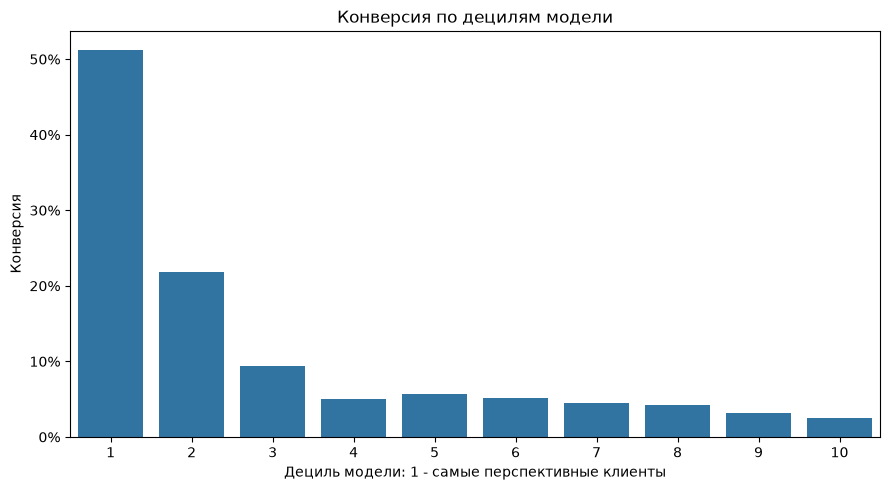

In [46]:
plt.figure(figsize=(9, 5))
sns.barplot(data=decile_summary, x="score_decile", y="conversion")
plt.title("Конверсия по децилям модели")
plt.xlabel("Дециль модели: 1 - самые перспективные клиенты")
plt.ylabel("Конверсия")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "08_model_decile_conversion.png", dpi=200)
plt.show()

### График прибыли по стратегиям обзвона

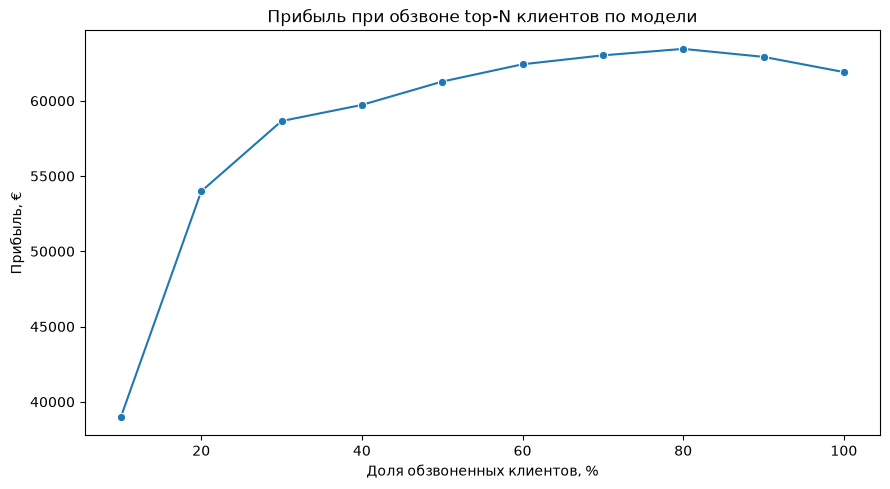

In [47]:
strategy_plot = strategy_summary.copy()
strategy_plot["called_share_percent"] = strategy_plot["called_share"] * 100

plt.figure(figsize=(9, 5))
sns.lineplot(data=strategy_plot, x="called_share_percent", y="profit", marker="o")
plt.title("Прибыль при обзвоне top-N клиентов по модели")
plt.xlabel("Доля обзвоненных клиентов, %")
plt.ylabel("Прибыль, €")
plt.tight_layout()
plt.savefig(figures_path / "09_model_strategy_profit.png", dpi=200)
plt.show()

### Важность признаков

In [48]:
trained_preprocessor = model.named_steps["preprocessor"]
trained_classifier = model.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()
coefficients = trained_classifier.coef_[0]

feature_importance = pd.DataFrame({
  "feature": feature_names,
  "coefficient": coefficients,
  "abs_coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values("abs_coefficient", ascending=False)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
4,num__emp.var.rate,-2.185873,2.185873
49,cat__month_mar,1.278950,1.278950
5,num__cons.price.idx,1.035738,1.035738
48,cat__month_jun,-0.766076,0.766076
50,cat__month_may,-0.647127,0.647127
51,cat__month_nov,-0.582214,0.582214
7,num__euribor3m,0.541962,0.541962
45,cat__month_aug,0.451413,0.451413
46,cat__month_dec,0.423984,0.423984
14,cat__job_retired,0.355732,0.355732


### Сохраняем результаты модели

In [49]:
decile_summary.to_csv(tables_path / "model_decile_summary.csv", index=False)
strategy_summary.to_csv(tables_path / "model_strategy_summary.csv", index=False)
feature_importance.to_csv(tables_path / "model_feature_importance.csv", index=False)

print("Результаты модели сохранены")

Результаты модели сохранены


### Конверсия по децилям модели

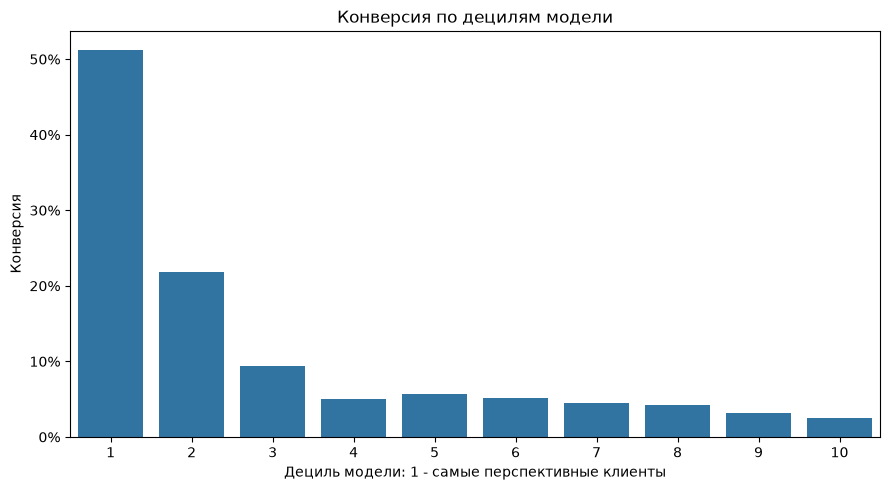

In [50]:
plt.figure(figsize=(9, 5))
sns.barplot(data=decile_summary, x="score_decile", y="conversion")
plt.title("Конверсия по децилям модели")
plt.xlabel("Дециль модели: 1 - самые перспективные клиенты")
plt.ylabel("Конверсия")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig(figures_path / "08_model_decile_conversion.png", dpi=200)
plt.show()

### Прибыль по стратегиям обзвона

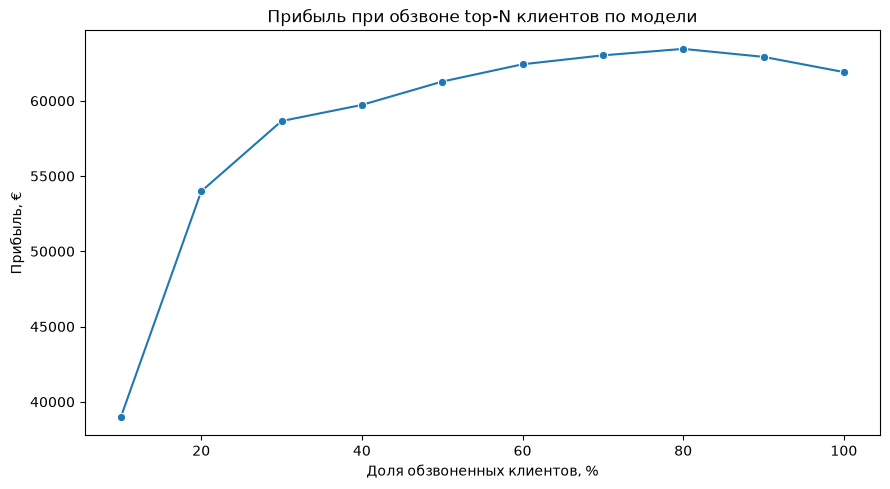

In [51]:
strategy_plot = strategy_summary.copy()
strategy_plot["called_share_percent"] = strategy_plot["called_share"] * 100

plt.figure(figsize=(9, 5))
sns.lineplot(data=strategy_plot, x="called_share_percent", y="profit", marker="o")
plt.title("Прибыль при обзвоне top-N клиентов по модели")
plt.xlabel("Доля обзвоненных клиентов, %")
plt.ylabel("Прибыль, €")
plt.tight_layout()
plt.savefig(figures_path / "09_model_strategy_profit.png", dpi=200)
plt.show()

### Важность признаков

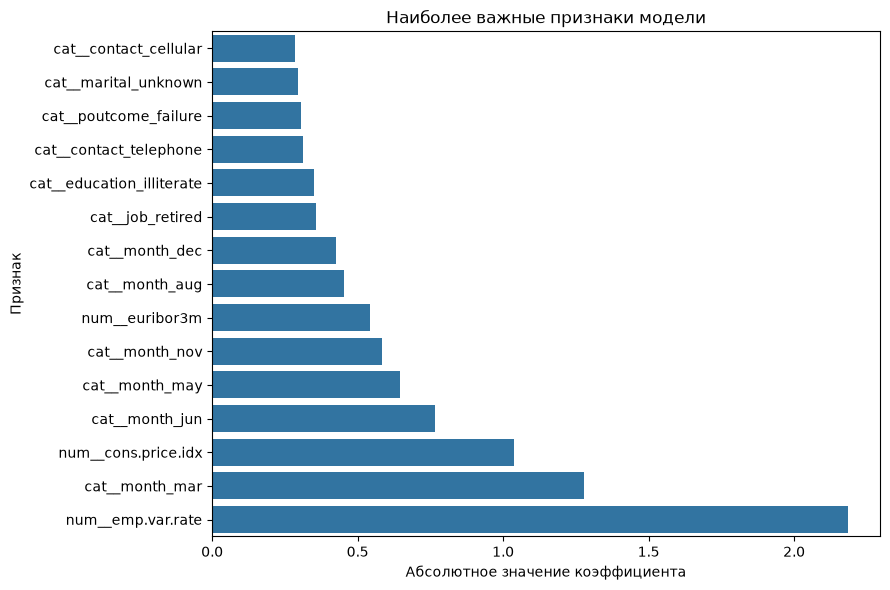

In [52]:
top_features = feature_importance.head(15).copy()
top_features = top_features.sort_values("abs_coefficient", ascending=True)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_features, x="abs_coefficient", y="feature")
plt.title("Наиболее важные признаки модели")
plt.xlabel("Абсолютное значение коэффициента")
plt.ylabel("Признак")
plt.tight_layout()
plt.savefig(figures_path / "10_model_feature_importance.png", dpi=200)
plt.show()

### Финальные выводы для презентации

In [53]:
final_summary = f"""
# Финальные выводы

## 1. Насколько успешна кампания

В выборке {clients:,} клиентов, из них {deposits:,} оформили срочный депозит.
Общая конверсия составила {conversion:.2%}.

При предположениях:
- стоимость звонка: {call_cost} €
- выручка с депозита: {revenue_per_deposit} €

кампания дает:
- затраты: {total_cost:,.0f} €
- выручку: {total_revenue:,.0f} €
- прибыль: {profit:,.0f} €
- ROI: {roi:.2%}

Точка безубыточности равна {break_even_conversion:.2%}, поэтому фактическая конверсия выше минимально необходимой.

## 2. Что связано с конверсией

Наиболее заметные закономерности:

- cellular показывает конверсию 14.7%, telephone - 5.2%;
- клиенты с прошлым успешным контактом имеют конверсию 65.1%;
- студенты и пенсионеры конвертируются лучше большинства профессий;
- месяцы mar, sep, oct, dec дают высокую конверсию, но имеют небольшой объем;
- duration сильно связан с успехом, но его нельзя использовать для отбора клиентов до звонка.

## 3. Можно ли улучшить кампанию сегментацией

Да. Модель без признака duration получила ROC-AUC 0.805.

Top-10% клиентов по модели дают конверсию 51.2% и покрывают 45.4% всех депозитов в тестовой выборке.
Top-20% клиентов дают 64.8% всех депозитов.

Если цель - максимальная прибыль, модель предлагает не обзванивать худшие 20% клиентов:
- прибыль при обзвоне всех: 61 909 €
- прибыль при обзвоне top-80%: 63 449 €

Если цель - максимальная эффективность операторов, лучше начинать с top-20% клиентов:
- конверсия: 36.5%
- ROI: 873.9%

## 4. Главный ответ

Маркетинг через обзвон в целом прибыльный, но не оптимальный.
Лучший подход - не звонить всем подряд, а использовать скоринг клиентов:
сначала обзванивать наиболее перспективные сегменты, а низкоскоринговых клиентов исключать или обрабатывать более дешевыми каналами.
"""

summary_path = outputs_path / "summary.md"

with open(summary_path, "w", encoding="utf-8") as file:
  file.write(final_summary)

print(final_summary)


# Финальные выводы

## 1. Насколько успешна кампания

В выборке 41,188 клиентов, из них 4,640 оформили срочный депозит.
Общая конверсия составила 11.27%.

При предположениях:
- стоимость звонка: 3 €
- выручка с депозита: 80 €

кампания дает:
- затраты: 123,564 €
- выручку: 371,200 €
- прибыль: 247,636 €
- ROI: 200.41%

Точка безубыточности равна 3.75%, поэтому фактическая конверсия выше минимально необходимой.

## 2. Что связано с конверсией

Наиболее заметные закономерности:

- cellular показывает конверсию 14.7%, telephone - 5.2%;
- клиенты с прошлым успешным контактом имеют конверсию 65.1%;
- студенты и пенсионеры конвертируются лучше большинства профессий;
- месяцы mar, sep, oct, dec дают высокую конверсию, но имеют небольшой объем;
- duration сильно связан с успехом, но его нельзя использовать для отбора клиентов до звонка.

## 3. Можно ли улучшить кампанию сегментацией

Да. Модель без признака duration получила ROC-AUC 0.805.

Top-10% клиентов по модели дают конверсию 51.2% и по